In [22]:
import PySimpleGUI as sg
import pandas as pd

# --- Load CSV ---
df = pd.read_csv("Planet Habitability Data - Sheet1.csv")

def hz_score(semi_major_axis, hz_range):
    hz_min, hz_max = map(float, hz_range.replace(' AU','').split('-'))
    if hz_min <= semi_major_axis <= hz_max:
        return 100
    else:
        dist = min(abs(semi_major_axis - hz_min), abs(semi_major_axis - hz_max))
        score = max(0, 100 - dist*50) 
        return score

gas_scores = {
    'N2': 100,
    'O2': 100,
    'CO2': 50,
    'H2O': 90
}
def atmosphere_score(atmosphere_str):
    gases = [g.strip() for g in atmosphere_str.split(',')]
    scores = [gas_scores.get(g, 0) for g in gases]
    if scores:
        return sum(scores)/len(scores)
    else:
        return 0

def size_score(radius):
    ideal_radius = 1
    diff = abs(radius - ideal_radius)
    score = max (0, 100 - diff * 50)
    return score

def star_score(star_type):
   if star_type.startswith('G'):
       return 80
   elif star_type.startswith('K'):
       return 90
   elif star_type.startswith('M'):
       return 50
   else:
       return 40

def calculate_habitability(planet_dict):
    weights = {'Habitable Zone':0.45, 'Atmosphere':0.30, 'Planet Size':0.15, 'Star Type':0.10}
    return sum(planet_dict[key]*weights[key] for key in weights)

# --- GUI Layout ---
sg.theme('Light Brown 4')

layout = [
    [sg.Text('Choose Planet For Evaluation')],
    [sg.Input(key='-IN-', size=15),
     sg.Listbox(
         sorted(df['Planetary Name'].tolist()),
         no_scrollbar=True,
         size=(15,5),
         key='-LIST-',
         enable_events=True,
     )],
    [sg.Button('Submit')]
]
screen_width, screen_height = sg.Window.get_screen_size()
window = sg.Window('Habitability Calculator', layout, size=(screen_width, screen_height), finalize=True)

# --- Event Loop ---
while True:
    event, values = window.read()
    if event == sg.WIN_CLOSED:
        break

    # Update input box when a planet is clicked
    if event == '-LIST-':
        selected = values['-LIST-'][0]
        window['-IN-'].update(selected)

    # Calculate habitability on Submit
    if event == 'Submit':
        planet_name = values['-IN-']

        # Safety check
        if planet_name not in df['Planetary Name'].values:
            sg.popup("Please select a planet!")
            continue

        # Get planet data from CSV
        planet_row = df[df['Planetary Name'] == planet_name].iloc[0]

        # Compute each score using the functions
        planet_dict = {
            'Habitable Zone': hz_score(planet_row['Orbital Semi-Major Axis [AU]'],
                                       planet_row['Habitable Zone of Star']),
            'Atmosphere': atmosphere_score(planet_row['Atmosphere']),
            'Planet Size': size_score(planet_row['Planet Radius [Earth Radius]']),
            'Star Type': star_score(planet_row['Star Type'])
        }

        # Calculate final habitability
        score = calculate_habitability(planet_dict)

        # Show result
        sg.popup(f"{planet_name} Habitability Score: {score:.1f}%")

window.close()


In [25]:
import PySimpleGUI as sg
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time

# --- Load CSV ---
df = pd.read_csv("Planet Habitability Data - Sheet1.csv")

# --- Habitability scoring functions ---
def hz_score(semi_major_axis, hz_range):
    hz_min, hz_max = map(float, hz_range.replace(' AU','').split('-'))
    if hz_min <= semi_major_axis <= hz_max:
        return 100
    else:
        dist = min(abs(semi_major_axis - hz_min), abs(semi_major_axis - hz_max))
        score = max(0, 100 - dist*50) 
        return score

# Gas-based atmosphere scoring
gas_scores = {
    'N2': 100,
    'O2': 100,
    'CO2': 50,
    'H2O': 90
}
def atmosphere_score(atmosphere_str):
    gases = [g.strip() for g in atmosphere_str.split(',')]
    scores = [gas_scores.get(g, 0) for g in gases]
    return sum(scores)/len(scores) if scores else 0

def size_score(radius):
    ideal_radius = 1
    diff = abs(radius - ideal_radius)
    return max(0, 100 - diff * 50)

def star_score(star_type):
   if star_type.startswith('G') or star_type.startswith('K'):
       return 100
   elif star_type.startswith('M'):
       return 50
   else:
       return 40

def calculate_habitability(planet_dict):
    weights = {'Habitable Zone':0.45, 'Atmosphere':0.30, 'Planet Size':0.15, 'Star Type':0.10}
    return sum(planet_dict[key]*weights[key] for key in weights)

# --- Planet animation function ---
def animate_planet(score, planet_name):
    fig, ax = plt.subplots()
    ax.set_aspect('equal')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # Planet outline
    planet = patches.Circle((0.5, 0.5), 0.4, edgecolor='black', facecolor='white', linewidth=2)
    ax.add_patch(planet)

    # Fill rectangle inside planet
    color = 'green' if score >= 80 else 'yellow' if score >= 50 else 'red'
    fill_height = 0
    target_height = 0.8 * (score / 100)
    fill_rect = patches.Rectangle((0.1, 0.1), 0.8, fill_height, color=color)
    ax.add_patch(fill_rect)

    # Planet name
    ax.text(0.5, 0.95, planet_name, ha='center', fontsize=14, weight='bold')

    plt.ion()
    plt.show()

    steps = 50
    for i in range(steps + 1):
        fill_rect.set_height(target_height * i / steps)
        fig.canvas.draw()
        fig.canvas.flush_events()
        time.sleep(0.02)

    plt.ioff()
    plt.show()

# --- GUI Layout ---
sg.theme('Light Brown 4')

layout = [
    [sg.Text('Choose Planet For Evaluation')],
    [sg.Input(key='-IN-', expand_x=True),
     sg.Listbox(
         sorted(df['Planetary Name'].tolist()),
         no_scrollbar=True,
         size=(20,10),
         key='-LIST-',
         enable_events=True,
         expand_x=True,
         expand_y=True
     )],
    [sg.Button('Submit', expand_x=True)]
]

window = sg.Window('Habitability Calculator', layout, resizable=True, finalize=True)
window.maximize()  # Fill the screen

# --- Event Loop ---
while True:
    event, values = window.read()
    if event == sg.WIN_CLOSED:
        break

    # Update input box when a planet is clicked
    if event == '-LIST-':
        selected = values['-LIST-'][0]
        window['-IN-'].update(selected)

    # Calculate habitability on Submit
    if event == 'Submit':
        planet_name = values['-IN-']

        if planet_name not in df['Planetary Name'].values:
            sg.popup("Please select a planet!")
            continue

        planet_row = df[df['Planetary Name'] == planet_name].iloc[0]

        planet_dict = {
            'Habitable Zone': hz_score(planet_row['Orbital Semi-Major Axis [AU]'],
                                       planet_row['Habitable Zone of Star']),
            'Atmosphere': atmosphere_score(planet_row['Atmosphere']),
            'Planet Size': size_score(planet_row['Planet Radius [Earth Radius]']),
            'Star Type': star_score(planet_row['Star Type'])
        }

        score = calculate_habitability(planet_dict)

        sg.popup(f"{planet_name} Habitability Score: {score:.1f}%")

        # Animate the planet
        animate_planet(score, planet_name)

window.close()


In [111]:
import PySimpleGUI as sg
import pandas as pd
import time
import math
import random

# --- Load CSV ---
df = pd.read_csv("Planet Habitability Data - Sheet1.csv")

# --- Habitability scoring functions ---
def hz_score(semi_major_axis, hz_range):
    hz_min, hz_max = map(float, hz_range.replace(' AU','').split('-'))
    if hz_min <= semi_major_axis <= hz_max:
        return 100
    else:
        dist = min(abs(semi_major_axis - hz_min), abs(semi_major_axis - hz_max))
        return max(0, 100 - dist*50)

gas_scores = {'N2':100,'O2':100,'CO2':50,'H2O':90}
def atmosphere_score(atmosphere_str):
    gases = [g.strip() for g in atmosphere_str.split(',')]
    scores = [gas_scores.get(g,0) for g in gases]
    return sum(scores)/len(scores) if scores else 0

def size_score(radius):
    ideal_radius = 1
    diff = abs(radius - ideal_radius)
    return max(0, 100 - diff * 50)

def star_score(star_type):
    if star_type.startswith('G') or star_type.startswith('K'):
        return 100
    elif star_type.startswith('M'):
        return 50
    else:
        return 40

def calculate_habitability(planet_dict):
    weights = {'Habitable Zone':0.45,'Atmosphere':0.30,'Planet Size':0.15,'Star Type':0.10}
    return sum(planet_dict[key]*weights[key] for key in weights)

# --- NASA retro CRT-style planet animation ---
def animate_planet_nasa_crt(graph, score, planet_name):
    graph.erase()
    w, h = graph.get_size()
    cx, cy = w / 2, h / 2
    radius = min(w, h) / 4

    outline_color = 'green'
    fill_color = 'green'
    bg_color = 'black'

    points = 100
    steps = 80
    flicker_range = 30  # flicker randomness

    # Precompute wireframe points
    wireframe = []
    for i in range(points):
        angle1 = i * 2*math.pi / points
        angle2 = (i+1) * 2*math.pi / points
        x1 = cx + radius * math.cos(angle1)
        y1 = cy + radius * math.sin(angle1)
        x2 = cx + radius * math.cos(angle2)
        y2 = cy + radius * math.sin(angle2)
        wireframe.append(((x1, y1), (x2, y2)))

    # Animate fill
    target_height = 2 * radius * (score / 100)
    for step in range(steps + 1):
        graph.erase()

        # Draw wireframe
        for line in wireframe:
            graph.draw_line(line[0], line[1], color=outline_color)

        # Scanline fill with flicker
        fill_height = target_height * step / steps
        for y_offset in range(int(fill_height)):
            y = cy - radius + y_offset
            dx = (radius**2 - (y - cy)**2)**0.5
            # Flicker effect
            if random.randint(0, 100) > flicker_range:
                graph.draw_line((cx - dx, y), (cx + dx, y), color=fill_color)

        # Slight glow around planet
        for glow in range(1,4):
            graph.draw_circle((cx, cy), radius + glow*3, line_color='dark green')

        # Text readouts with flicker
        margin = 10  # pixels from the edge
        w, h = graph.get_size()  # current size of the Graph


        if random.random() > 0.1:
            graph.draw_text(f"PLANET: {planet_name}", (margin, h - margin),
                    color='green', font=('Courier', 12))  # no anchor

        if random.random() > 0.1:
            graph.draw_text(f"HABITABILITY: {score:.1f}%", (margin, h - margin - 20),
                    color='green', font=('Courier', 12))  # no anchor



        window.refresh()
        time.sleep(0.02)

    # Final percentage inside planet
    graph.draw_text(f"{score:.1f}%", (cx, cy), color='white',
                    font=('Courier', 18, 'bold'))
    window.refresh()

# --- GUI Layout ---
sg.theme('DarkBlack')

layout = [
    [sg.Text('Choose Planet For Evaluation', text_color='green', font=('Courier',14))],
    [sg.Input(key='-IN-', expand_x=True, background_color='black', text_color='green'),
     sg.Listbox(sorted(df['Planetary Name'].tolist()),
                size=(20,10),
                key='-LIST-',
                enable_events=True,
                expand_x=True,
                expand_y=True,
                background_color='black',
                text_color='green')],
    [sg.Button('Submit', expand_x=True)],
    [sg.Graph(canvas_size=(600,600),
              graph_bottom_left=(0,0),
              graph_top_right=(600,600),
              key='-GRAPH-',
              background_color='black',
              expand_x=True,
              expand_y=True)]
]

window = sg.Window('Habitability Calculator', layout, resizable=True, finalize=True)
window.maximize()

# --- Event Loop ---
while True:
    event, values = window.read()
    if event == sg.WIN_CLOSED:
        break

    if event == '-LIST-':
        selected = values['-LIST-'][0]
        window['-IN-'].update(selected)

    if event == 'Submit':
        planet_name = values['-IN-']
        if planet_name not in df['Planetary Name'].values:
            sg.popup("Please select a planet!")
            continue

        planet_row = df[df['Planetary Name'] == planet_name].iloc[0]

        planet_dict = {
            'Habitable Zone': hz_score(planet_row['Orbital Semi-Major Axis [AU]'],
                                       planet_row['Habitable Zone of Star']),
            'Atmosphere': atmosphere_score(planet_row['Atmosphere']),
            'Planet Size': size_score(planet_row['Planet Radius [Earth Radius]']),
            'Star Type': star_score(planet_row['Star Type'])
        }

        score = calculate_habitability(planet_dict)
        animate_planet_nasa_crt(window['-GRAPH-'], score, planet_name)
window.close()

In [13]:
import PySimpleGUI as sg
import pandas as pd
import time
import math
import random

# --- Load CSV ---
df = pd.read_csv("Planet Habitability Data - Sheet1.csv")

# --- Habitability scoring functions ---
def hz_score(semi_major_axis, hz_range):
    hz_min, hz_max = map(float, hz_range.replace(' AU','').split('-'))
    if hz_min <= semi_major_axis <= hz_max:
        return 100
    else:
        dist = min(abs(semi_major_axis - hz_min), abs(semi_major_axis - hz_max))
        return max(0, 100 - dist*50)

gas_scores = {'N2':100,'O2':100,'CO2':50,'H2O':90}
def atmosphere_score(atmosphere_str):
    gases = [g.strip() for g in atmosphere_str.split(',')]
    scores = [gas_scores.get(g,0) for g in gases]
    return sum(scores)/len(scores) if scores else 0

def size_score(radius):
    ideal_radius = 1
    diff = abs(radius - ideal_radius)
    return max(0, 100 - diff * 50)

def star_score(star_type):
    if star_type.startswith('G') or star_type.startswith('K'):
        return 100
    elif star_type.startswith('M'):
        return 50
    else:
        return 40

def calculate_habitability(planet_dict):
    weights = {'Habitable Zone':0.45,'Atmosphere':0.30,'Planet Size':0.15,'Star Type':0.10}
    return sum(planet_dict[key]*weights[key] for key in weights)

# --- NASA CRT-style planet animation ---
def animate_planet_nasa_crt(graph, score, planet_name):
    graph.erase()
    w, h = graph.get_size()
    cx, cy = w / 2, h / 2
    radius = min(w, h) / 4

    outline_color = 'green'
    fill_color = 'green'
    points = 100
    steps = 50
    flicker_range = 30

    # Precompute wireframe points
    wireframe = []
    for i in range(points):
        angle1 = i * 2*math.pi / points
        angle2 = (i+1) * 2*math.pi / points
        x1 = cx + radius * math.cos(angle1)
        y1 = cy + radius * math.sin(angle1)
        x2 = cx + radius * math.cos(angle2)
        y2 = cy + radius * math.sin(angle2)
        wireframe.append(((x1, y1), (x2, y2)))

    # Margins for side labels
    left_margin = 10
    bottom_margin = 30

    target_height = 2 * radius * (score / 100)
    for step in range(steps + 1):
        graph.erase()

        # Draw wireframe
        for line in wireframe:
            graph.draw_line(line[0], line[1], color=outline_color)

        # Scanline fill with flicker
        fill_height = target_height * step / steps
        for y_offset in range(int(fill_height)):
            y = cy - radius + y_offset
            dx = (radius**2 - (y - cy)**2)**0.5
            if random.randint(0, 100) > flicker_range:
                graph.draw_line((cx - dx, y), (cx + dx, y), color=fill_color)

        # Slight glow around planet
        for glow in range(1,4):
            graph.draw_circle((cx, cy), radius + glow*3, line_color='dark green')

        # Side labels with flicker
        if random.random() > 0.1:
            graph.draw_text(f"PLANET: {planet_name}", (left_margin, bottom_margin),
                            color='green', font=('Courier', 12))
        if random.random() > 0.1:
            graph.draw_text(f"HABITABILITY: {score:.1f}%", (left_margin, bottom_margin + 20),
                            color='green', font=('Courier', 12))

        # Draw computing text on top of planet while filling
        graph.draw_text("COMPUTING...", (cx, cy), color='yellow', font=('Courier', 16, 'bold'))

        window.refresh()
        time.sleep(0.05)

    graph.erase()
    # Redraw planet outline and fill one last time
    for line in wireframe:
        graph.draw_line(line[0], line[1], color=outline_color)
    for y_offset in range(int(target_height)):
        y = cy - radius + y_offset
        dx = (radius**2 - (y - cy)**2)**0.5
        graph.draw_line((cx - dx, y), (cx + dx, y), color=fill_color)

    # Glow and final percentage
    for glow in range(1,4):
        graph.draw_circle((cx, cy), radius + glow*3, line_color='dark green')
    graph.draw_text(f"{score:.1f}%", (cx, cy), color='white', font=('Courier', 18, 'bold'))
    window.refresh()



# --- GUI Layout ---
sg.theme('DarkBlack')

layout = [
    [sg.Text('Choose Planet For Evaluation', text_color='green', font=('Courier',14))],
    [sg.Input(key='-IN-', expand_x=True, background_color='black', text_color='green'),
     sg.Listbox(sorted(df['Planetary Name'].tolist()),
                size=(20,10),
                key='-LIST-',
                enable_events=True,
                expand_x=True,
                expand_y=True,
                background_color='black',
                text_color='green')],
    [sg.Button('Submit', expand_x=True)],
    [sg.Graph(canvas_size=(600,600),
              graph_bottom_left=(0,0),
              graph_top_right=(600,600),
              key='-GRAPH-',
              background_color='black',
              expand_x=True,
              expand_y=True)]
]

window = sg.Window('NASA CRT Habitability Calculator', layout, resizable=True, finalize=True)
window.maximize()

# --- Event Loop ---
while True:
    event, values = window.read()
    if event == sg.WIN_CLOSED:
        break

    # Update input box when a planet is clicked
    if event == '-LIST-':
        selected = values['-LIST-'][0]
        window['-IN-'].update(selected)

    # Calculate habitability only when Submit is clicked
    if event == 'Submit':
        planet_name = values['-IN-']
        if planet_name not in df['Planetary Name'].values:
            sg.popup("Please select a planet!")
            continue

        planet_row = df[df['Planetary Name'] == planet_name].iloc[0]

        planet_dict = {
            'Habitable Zone': hz_score(planet_row['Orbital Semi-Major Axis [AU]'],
                                       planet_row['Habitable Zone of Star']),
            'Atmosphere': atmosphere_score(planet_row['Atmosphere']),
            'Planet Size': size_score(planet_row['Planet Radius [Earth Radius]']),
            'Star Type': star_score(planet_row['Star Type'])
        }

        score = calculate_habitability(planet_dict)
        animate_planet_nasa_crt(window['-GRAPH-'], score, planet_name)

window.close()


In [17]:
import PySimpleGUI as sg
import pandas as pd
import time
import math
import random
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

# --- Load CSV ---
df = pd.read_csv("Planet Habitability Data - Sheet1.csv")

# --- Habitability scoring functions ---
def hz_score(semi_major_axis, hz_range):
    hz_min, hz_max = map(float, hz_range.replace(' AU','').split('-'))
    if hz_min <= semi_major_axis <= hz_max:
        return 100
    else:
        dist = min(abs(semi_major_axis - hz_min), abs(semi_major_axis - hz_max))
        return max(0, 100 - dist*50)

gas_scores = {'N2':100,'O2':100,'CO2':50,'H2O':90}
def atmosphere_score(atmosphere_str):
    gases = [g.strip() for g in atmosphere_str.split(',')]
    scores = [gas_scores.get(g,0) for g in gases]
    return sum(scores)/len(scores) if scores else 0

def size_score(radius):
    ideal_radius = 1
    diff = abs(radius - ideal_radius)
    return max(0, 100 - diff * 50)

def star_score(star_type):
    if star_type.startswith('G') or star_type.startswith('K'):
        return 100
    elif star_type.startswith('M'):
        return 50
    else:
        return 40

def calculate_habitability(planet_dict):
    weights = {'Habitable Zone':0.45,'Atmosphere':0.30,'Planet Size':0.15,'Star Type':0.10}
    return sum(planet_dict[key]*weights[key] for key in weights)

# --- Matplotlib helper ---
def draw_figure(canvas, figure):
    figure_canvas_agg = FigureCanvasTkAgg(figure, canvas)
    figure_canvas_agg.draw()
    figure_canvas_agg.get_tk_widget().pack(side='top', fill='both', expand=1)
    return figure_canvas_agg

# --- GUI Layout ---
sg.theme('DarkBlack')
layout = [
    [sg.Text('Choose Planet For Evaluation', text_color='green', font=('Courier',14))],
    [sg.Input(key='-IN-', expand_x=True, background_color='black', text_color='green'),
     sg.Listbox(sorted(df['Planetary Name'].tolist()), size=(20,10),
                key='-LIST-', enable_events=True, expand_x=True, expand_y=True,
                background_color='black', text_color='green')],
    [sg.Button('Submit'), sg.Button('View Plot', key='-PLOT-', visible=False)],
    [sg.Graph(canvas_size=(600,600), graph_bottom_left=(0,0),
              graph_top_right=(600,600), key='-GRAPH-', background_color='black',
              expand_x=True, expand_y=True)]
]

window = sg.Window('NASA CRT Habitability Calculator', layout, resizable=True, finalize=True)
window.maximize()

# --- Helper: prepare plot data ---
def get_plot_data():
    planet_names = []
    habit_scores = []
    hz_mids = []
    for idx, row in df.iterrows():
        planet_names.append(row['Planetary Name'])
        hab_score = calculate_habitability({
            'Habitable Zone': hz_score(row['Orbital Semi-Major Axis [AU]'], row['Habitable Zone of Star']),
            'Atmosphere': atmosphere_score(row['Atmosphere']),
            'Planet Size': size_score(row['Planet Radius [Earth Radius]']),
            'Star Type': star_score(row['Star Type'])
        })
        habit_scores.append(hab_score)
        hz_min, hz_max = map(float, row['Habitable Zone of Star'].replace(' AU','').split('-'))
        hz_mids.append((hz_min+hz_max)/2)
    return planet_names, habit_scores, hz_mids

# --- CRT-style planet animation (simplified for brevity) ---
def animate_planet_nasa_crt(graph, score, planet_name):
    graph.erase()
    w, h = graph.get_size()
    cx, cy = w/2, h/2
    radius = min(w,h)/4
    # Simple fill
    target_height = 2*radius*(score/100)
    for step in range(50):
        graph.erase()
        fill_height = target_height*step/50
        for y_offset in range(int(fill_height)):
            y = cy-radius + y_offset
            dx = (radius**2-(y-cy)**2)**0.5
            graph.draw_line((cx-dx,y),(cx+dx,y), color='green')
        graph.draw_text(f"{planet_name}", (cx,h-20), color='white', font=('Courier',18))
        graph.draw_text(f"Habitability: {score:.1f}%", (cx,cy), color='white', font=('Courier',14))
        window.refresh()
        time.sleep(0.02)
    window['-PLOT-'].update(visible=True)

# --- Event loop ---
while True:
    event, values = window.read()
    if event == sg.WIN_CLOSED:
        break
    if event == '-LIST-':
        window['-IN-'].update(values['-LIST-'][0])
    if event == 'Submit':
        planet_name = values['-IN-']
        if planet_name not in df['Planetary Name'].values:
            sg.popup("Please select a planet!")
            continue
        planet_row = df[df['Planetary Name']==planet_name].iloc[0]
        score = calculate_habitability({
            'Habitable Zone': hz_score(planet_row['Orbital Semi-Major Axis [AU]'], planet_row['Habitable Zone of Star']),
            'Atmosphere': atmosphere_score(planet_row['Atmosphere']),
            'Planet Size': size_score(planet_row['Planet Radius [Earth Radius]']),
            'Star Type': star_score(planet_row['Star Type'])
        })
        animate_planet_nasa_crt(window['-GRAPH-'], score, planet_name)
    if event == '-PLOT-':
        planets, scores, hz_mid = get_plot_data()
        fig, ax = plt.subplots(figsize=(10,5))
        scatter = ax.scatter(planets, scores, c=hz_mid, cmap='plasma', s=150)
        ax.set_ylabel('Habitability Score (%)')
        ax.set_title('Planet vs Habitability vs Star Habitable Zone')
        ax.set_xticklabels(planets, rotation=45, ha='right')
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label("Star Habitable Zone Midpoint (AU)")
        # Show in PySimpleGUI
        plot_layout = [[sg.Canvas(key='-CANVAS-')],[sg.Button('Close')]]
        plot_window = sg.Window('Habitability Plot', plot_layout, finalize=True)
        draw_figure(plot_window['-CANVAS-'].TKCanvas, fig)
        while True:
            e,v = plot_window.read()
            if e in (sg.WIN_CLOSED,'Close'):
                break
        plot_window.close()

window.close()


In [31]:
import PySimpleGUI as sg
import pandas as pd
import time
import math
import random

# --- Load CSV ---
df = pd.read_csv("Planet Habitability Data - Sheet1.csv")

# --- Habitability scoring functions ---
def hz_score(semi_major_axis, hz_range):
    hz_min, hz_max = map(float, hz_range.replace(' AU','').split('-'))
    if hz_min <= semi_major_axis <= hz_max:
        return 100
    else:
        dist = min(abs(semi_major_axis - hz_min), abs(semi_major_axis - hz_max))
        return max(0, 100 - dist*50)

gas_scores = {'N2':100,'O2':100,'CO2':50,'H2O':90}
def atmosphere_score(atmosphere_str):
    gases = [g.strip() for g in atmosphere_str.split(',')]
    scores = [gas_scores.get(g,0) for g in gases]
    return sum(scores)/len(scores) if scores else 0

def size_score(radius):
    ideal_radius = 1
    diff = abs(radius - ideal_radius)
    return max(0, 100 - diff * 50)

def star_score(star_type):
    if star_type.startswith('G') or star_type.startswith('K'):
        return 100
    elif star_type.startswith('M'):
        return 50
    else:
        return 40

def calculate_habitability(planet_dict):
    weights = {'Habitable Zone':0.45,'Atmosphere':0.30,'Planet Size':0.15,'Star Type':0.10}
    return sum(planet_dict[key]*weights[key] for key in weights)

# --- NASA CRT-style animation ---
def animate_planet_nasa_crt(graph, score, planet_name):
    graph.erase()
    w, h = graph.get_size()
    cx, cy = w / 2, h / 2
    radius = min(w, h) / 4

    outline_color = 'green'
    fill_color = 'green'
    margin = 20

    steps = 80
    flicker_range = 30

    # Precompute wireframe points
    points = 100
    wireframe = []
    for i in range(points):
        angle1 = i * 2*math.pi / points
        angle2 = (i+1) * 2*math.pi / points
        x1 = cx + radius * math.cos(angle1)
        y1 = cy + radius * math.sin(angle1)
        x2 = cx + radius * math.cos(angle2)
        y2 = cy + radius * math.sin(angle2)
        wireframe.append(((x1, y1), (x2, y2)))

    # Animate fill with "Computing..."
    target_height = 2 * radius * (score / 100)
    for step in range(steps + 1):
        graph.erase()
        
        # Planet name at top
        graph.draw_text(planet_name, (cx, h - margin), color='white', font=('Courier', 20, 'bold'))

        # Wireframe
        for line in wireframe:
            graph.draw_line(line[0], line[1], color=outline_color)

        # Scanline fill with flicker
        fill_height = target_height * step / steps
        for y_offset in range(int(fill_height)):
            y = cy - radius + y_offset
            dx = (radius**2 - (y - cy)**2)**0.5
            if random.randint(0, 100) > flicker_range:
                graph.draw_line((cx - dx, y), (cx + dx, y), color=fill_color)

        # Glow
        for glow in range(1,4):
            graph.draw_circle((cx, cy), radius + glow*3, line_color='dark green')

        # Side readouts
        graph.draw_text(f"PLANET: {planet_name}", (margin, h - margin - 40), color='green', font=('Courier', 12))
        graph.draw_text(f"HABITABILITY: {score:.1f}%", (margin, h - margin - 60), color='green', font=('Courier', 12))

        # Computing message
        graph.draw_text("Computing...", (cx, margin), color='green', font=('Courier', 14))

        window.refresh()
        time.sleep(0.03)

    # --- After fill complete: "Calculation Complete!" ---
    graph.erase()
    
    # Draw fully filled planet
    for y_offset in range(int(target_height)):
        y = cy - radius + y_offset
        dx = (radius**2 - (y - cy)**2)**0.5
        graph.draw_line((cx - dx, y), (cx + dx, y), color=fill_color)
    
    # Wireframe and glow
    for line in wireframe:
        graph.draw_line(line[0], line[1], color=outline_color)
    for glow in range(1,4):
        graph.draw_circle((cx, cy), radius + glow*3, line_color='dark green')

    # Text updates
    graph.draw_text("Calculation Complete!", (cx, margin), color='green', font=('Courier', 16, 'bold'))
    window.refresh()
    time.sleep(1)  # pause 1 second to show "Calculation Complete!"

    # Final display: planet name + probability
    graph.erase()
    for y_offset in range(int(target_height)):
        y = cy - radius + y_offset
        dx = (radius**2 - (y - cy)**2)**0.5
        graph.draw_line((cx - dx, y), (cx + dx, y), color=fill_color)
    for line in wireframe:
        graph.draw_line(line[0], line[1], color=outline_color)
    for glow in range(1,4):
        graph.draw_circle((cx, cy), radius + glow*3, line_color='dark green')

    # Final text
    graph.draw_text(f"{planet_name} Probability: {score:.1f}%", (cx, cy), color='white', font=('Courier', 18, 'bold'))
    window.refresh()


# --- GUI Layout ---
sg.theme('DarkBlack')
layout = [
    [sg.Text('Choose Planet For Evaluation', text_color='green', font=('Courier',14))],
    [sg.Input(key='-IN-', expand_x=True, background_color='black', text_color='green'),
     sg.Listbox(sorted(df['Planetary Name'].tolist()), size=(20,10),
                key='-LIST-', enable_events=True,
                expand_x=True, expand_y=True,
                background_color='black', text_color='green')],
    [sg.Button('Submit')],
    [sg.Graph(canvas_size=(600,600), graph_bottom_left=(0,0), graph_top_right=(600,600),
              key='-GRAPH-', background_color='black', expand_x=True, expand_y=True)]
]

window = sg.Window('NASA CRT Habitability Calculator', layout, resizable=True, finalize=True)
window.maximize()

# --- Event Loop ---
while True:
    event, values = window.read()
    if event == sg.WIN_CLOSED:
        break

    if event == '-LIST-':
        selected = values['-LIST-'][0]
        window['-IN-'].update(selected)

    if event == 'Submit':
        planet_name = values['-IN-']
        if planet_name not in df['Planetary Name'].values:
            sg.popup("Please select a planet!")
            continue

        planet_row = df[df['Planetary Name'] == planet_name].iloc[0]
        planet_dict = {
            'Habitable Zone': hz_score(planet_row['Orbital Semi-Major Axis [AU]'],
                                       planet_row['Habitable Zone of Star']),
            'Atmosphere': atmosphere_score(planet_row['Atmosphere']),
            'Planet Size': size_score(planet_row['Planet Radius [Earth Radius]']),
            'Star Type': star_score(planet_row['Star Type'])
        }
        score = calculate_habitability(planet_dict)
        animate_planet_nasa_crt(window['-GRAPH-'], score, planet_name)

window.close()


In [59]:
import PySimpleGUI as sg
import pandas as pd
import time
import math
import random

# --- Load CSV ---
df = pd.read_csv("Planet Habitability Data - Sheet1.csv")

# --- Habitability scoring functions ---
def hz_score(semi_major_axis, hz_range):
    hz_min, hz_max = map(float, hz_range.replace(' AU','').split('-'))
    if hz_min <= semi_major_axis <= hz_max:
        return 100
    else:
        dist = min(abs(semi_major_axis - hz_min), abs(semi_major_axis - hz_max))
        return max(0, 100 - dist*50)

gas_scores = {'N2':100,'O2':100,'CO2':50,'H2O':90}
def atmosphere_score(atmosphere_str):
    gases = [g.strip() for g in atmosphere_str.split(',')]
    scores = [gas_scores.get(g,0) for g in gases]
    return sum(scores)/len(scores) if scores else 0

def size_score(radius):
    ideal_radius = 1
    diff = abs(radius - ideal_radius)
    return max(0, 100 - diff * 50)

def star_score(star_type):
    if star_type.startswith('G') or star_type.startswith('K'):
        return 100
    elif star_type.startswith('M'):
        return 50
    else:
        return 40

def calculate_habitability(planet_dict):
    weights = {'Habitable Zone':0.45,'Atmosphere':0.30,'Planet Size':0.15,'Star Type':0.10}
    return sum(planet_dict[key]*weights[key] for key in weights)


def plot_habitability(df):
    planets = []
    scores = []
    hz_mid = []
    for idx, row in df.iterrows():
        planets.append(row['Planetary Name'])
        hab_score = calculate_habitability({
            'Habitable Zone': hz_score(row['Orbital Semi-Major Axis [AU]'], row['Habitable Zone of Star']),
            'Atmosphere': atmosphere_score(row['Atmosphere']),
            'Planet Size': size_score(row['Planet Radius [Earth Radius]']),
            'Star Type': star_score(row['Star Type'])
        })
        scores.append(hab_score)
        try:
            hz_min, hz_max = map(float, str(row['Habitable Zone of Star']).replace(' AU','').split('-'))
        except:
            hz_min, hz_max = 0, 0
        hz_mid.append((hz_min + hz_max)/2)

    fig, ax = plt.subplots(figsize=(12,6))
    scatter = ax.scatter(planets, scores, c=hz_mid, cmap='plasma', s=150)
    ax.set_ylabel("Habitability Score")
    ax.set_xlabel("Planet")
    ax.set_title("Planet Habitability vs Star Habitable Zone")
    plt.xticks(rotation=45, ha='right')
    cbar = plt.colorbar(scatter)
    cbar.set_label("HZ Center (AU)")
    plt.tight_layout()
    plt.show()
    
# --- NASA CRT-style animation ---
def animate_planet_nasa_crt(graph, score, planet_name):
    graph.erase()
    w, h = graph.get_size()
    cx, cy = w / 2, h / 2
    radius = min(w, h) / 4

    outline_color = 'green'
    fill_color = 'green'
    margin = 20

    steps = 80
    flicker_range = 30

    # Precompute wireframe points
    points = 100
    wireframe = []
    for i in range(points):
        angle1 = i * 2*math.pi / points
        angle2 = (i+1) * 2*math.pi / points
        x1 = cx + radius * math.cos(angle1)
        y1 = cy + radius * math.sin(angle1)
        x2 = cx + radius * math.cos(angle2)
        y2 = cy + radius * math.sin(angle2)
        wireframe.append(((x1, y1), (x2, y2)))

    # Animate fill with "Computing..."
    target_height = 2 * radius * (score / 100)
    for step in range(steps + 1):
        graph.erase()
        graph.draw_text(planet_name, (cx, h - margin), color='white', font=('Courier', 20, 'bold'))
        for line in wireframe:
            graph.draw_line(line[0], line[1], color=outline_color)
        fill_height = target_height * step / steps
        for y_offset in range(int(fill_height)):
            y = cy - radius + y_offset
            dx = (radius**2 - (y - cy)**2)**0.5
            if random.randint(0, 100) > flicker_range:
                graph.draw_line((cx - dx, y), (cx + dx, y), color=fill_color)
        for glow in range(1,4):
            graph.draw_circle((cx, cy), radius + glow*3, line_color='dark green')
        graph.draw_text(f"PLANET: {planet_name}", (20, h - 60), color='green', font=('Courier', 12))
        graph.draw_text(f"HABITABILITY: {score:.1f}%", (20, h - 80), color='green', font=('Courier', 12))
        graph.draw_text("Computing...", (cx, margin), color='green', font=('Courier', 14))
        window.refresh()
        time.sleep(0.03)

    # --- After fill complete: "Calculation Complete!" ---
    graph.erase()
    
    # Draw fully filled planet
    for y_offset in range(int(target_height)):
        y = cy - radius + y_offset
        dx = (radius**2 - (y - cy)**2)**0.5
        graph.draw_line((cx - dx, y), (cx + dx, y), color=fill_color)
    
    # Wireframe and glow
    for line in wireframe:
        graph.draw_line(line[0], line[1], color=outline_color)
    for glow in range(1,4):
        graph.draw_circle((cx, cy), radius + glow*3, line_color='dark green')

    # Text updates
    graph.draw_text("Calculation Complete!", (cx, margin), color='green', font=('Courier', 16, 'bold'))
    window.refresh()
    time.sleep(1)  # pause 1 second to show "Calculation Complete!"

    # Final display: planet name + probability
    graph.erase()
    for y_offset in range(int(target_height)):
        y = cy - radius + y_offset
        dx = (radius**2 - (y - cy)**2)**0.5
        graph.draw_line((cx - dx, y), (cx + dx, y), color=fill_color)
    for line in wireframe:
        graph.draw_line(line[0], line[1], color=outline_color)
    for glow in range(1,4):
        graph.draw_circle((cx, cy), radius + glow*3, line_color='dark green')

    # Final text
    graph.draw_text(f"{planet_name} Probability: {score:.1f}%", (cx, cy), color='white', font=('Courier', 18, 'bold'))
    window.refresh()


# --- GUI Layout ---
sg.theme('DarkBlack')
layout = [
    [sg.Text('Choose Planet For Evaluation', text_color='green', font=('Courier',14))],
    [sg.Input(key='-IN-', expand_x=True, background_color='black', text_color='green'),
     sg.Listbox(sorted(df['Planetary Name'].tolist()), size=(20,10),
                key='-LIST-', enable_events=True,
                expand_x=True, expand_y=True,
                background_color='black', text_color='green')],
    [sg.Button('Submit')],
    [sg.Graph(canvas_size=(600,600), graph_bottom_left=(0,0), graph_top_right=(600,600),
              key='-GRAPH-', background_color='black', expand_x=True, expand_y=True)]
]

window = sg.Window('NASA CRT Habitability Calculator', layout, resizable=True, finalize=True)
window.maximize()

# --- Event Loop ---
while True:
    event, values = window.read()
    if event == sg.WIN_CLOSED:
        break

    if event == '-LIST-':
        selected = values['-LIST-'][0]
        window['-IN-'].update(selected)

    if event == 'Submit':
        planet_name = values['-IN-']
        if planet_name not in df['Planetary Name'].values:
            sg.popup("Please select a planet!")
            continue

        planet_row = df[df['Planetary Name'] == planet_name].iloc[0]
        planet_dict = {
            'Habitable Zone': hz_score(planet_row['Orbital Semi-Major Axis [AU]'],
                                       planet_row['Habitable Zone of Star']),
            'Atmosphere': atmosphere_score(planet_row['Atmosphere']),
            'Planet Size': size_score(planet_row['Planet Radius [Earth Radius]']),
            'Star Type': star_score(planet_row['Star Type'])
        }
        score = calculate_habitability(planet_dict)
        animate_planet_nasa_crt(window['-GRAPH-'], score, planet_name)

    if not plot_button_added:
            window.extend_layout(window, [[sg.Button('Show Plot', key='-PLOT-')]])
            plot_button_added = True

window.close()


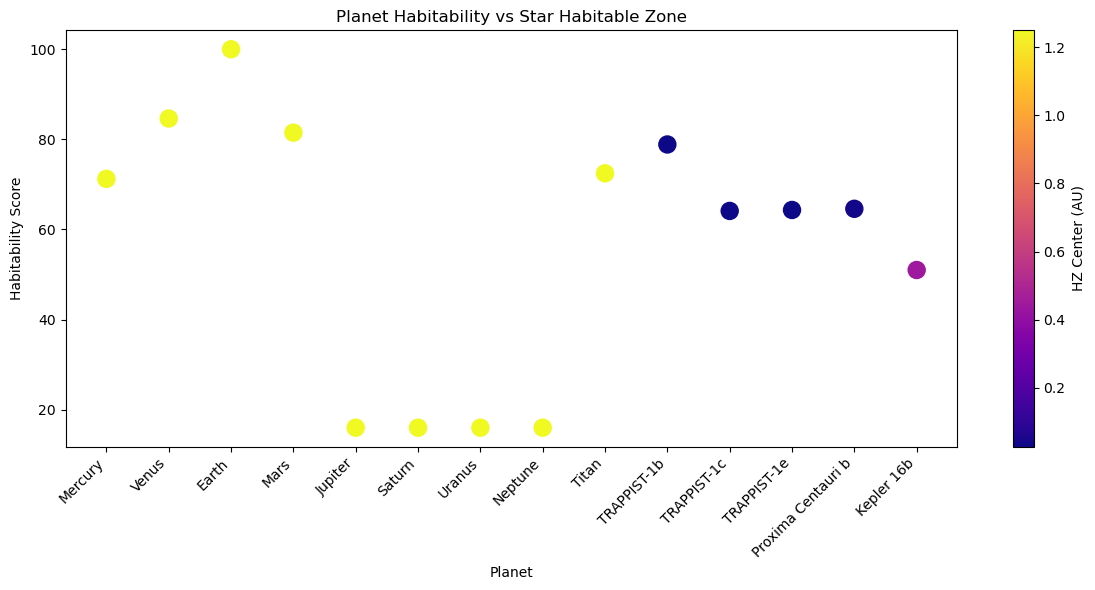

In [65]:
import PySimpleGUI as sg
import pandas as pd
import time
import math
import random
import matplotlib.pyplot as plt  # <-- needed for plotting

# --- Load CSV ---
df = pd.read_csv("Planet Habitability Data - Sheet1.csv")

# --- Habitability scoring functions ---
def hz_score(semi_major_axis, hz_range):
    try:
        hz_min, hz_max = map(float, str(hz_range).replace(' AU','').split('-'))
    except:
        return 0
    if hz_min <= semi_major_axis <= hz_max:
        return 100
    else:
        dist = min(abs(semi_major_axis - hz_min), abs(semi_major_axis - hz_max))
        return max(0, 100 - dist*50)

gas_scores = {'N2':100,'O2':100,'CO2':50,'H2O':90, 'H':20, 'He': 20, 'CH4':20}
def atmosphere_score(atmosphere_str):
    if pd.isna(atmosphere_str):
        return 0
    gases = [g.strip() for g in str(atmosphere_str).split(',')]
    scores = [gas_scores.get(g,0) for g in gases]
    return sum(scores)/len(scores) if scores else 0

def size_score(radius):
    if pd.isna(radius):
        return 0
    ideal_radius = 1
    diff = abs(radius - ideal_radius)
    return max(0, 100 - diff * 50)

def star_score(star_type):
    if pd.isna(star_type):
        return 0
    if star_type.startswith('G') or star_type.startswith('K'):
        return 100
    elif star_type.startswith('M'):
        return 50
    else:
        return 40

def calculate_habitability(planet_dict):
    weights = {'Habitable Zone':0.45,'Atmosphere':0.30,'Planet Size':0.15,'Star Type':0.10}
    return sum(planet_dict[key]*weights[key] for key in weights)

# --- Function to draw matplotlib figure in PySimpleGUI window ---
def draw_figure(canvas, figure):
    figure_canvas_agg = FigureCanvasTkAgg(figure, canvas)
    figure_canvas_agg.draw()
    figure_canvas_agg.get_tk_widget().pack(side='top', fill='both', expand=1)
    return figure_canvas_agg

# --- Plot function in new window ---
def plot_habitability_window(df):
    planets, scores, hz_mid = [], [], []
    for idx, row in df.iterrows():
        planets.append(row['Planetary Name'])
        hab_score = calculate_habitability({
            'Habitable Zone': hz_score(row['Orbital Semi-Major Axis [AU]'], row['Habitable Zone of Star']),
            'Atmosphere': atmosphere_score(row['Atmosphere']),
            'Planet Size': size_score(row['Planet Radius [Earth Radius]']),
            'Star Type': star_score(row['Star Type'])
        })
        scores.append(hab_score)
        try:
            hz_min, hz_max = map(float, str(row['Habitable Zone of Star']).replace(' AU','').split('-'))
        except:
            hz_min, hz_max = 0,0
        hz_mid.append((hz_min+hz_max)/2)

    fig, ax = plt.subplots(figsize=(12,6))
    scatter = ax.scatter(planets, scores, c=hz_mid, cmap='plasma', s=150)
    ax.set_ylabel("Habitability Score")
    ax.set_xlabel("Planet")
    ax.set_title("Planet Habitability vs Star Habitable Zone")
    plt.xticks(rotation=45, ha='right')
    cbar = plt.colorbar(scatter)
    cbar.set_label("HZ Center (AU)")
    plt.tight_layout()

    # PySimpleGUI Window
    plot_layout = [[sg.Canvas(key='-CANVAS-')],
                   [sg.Button('Close')]]
    plot_window = sg.Window("Habitability Plot", plot_layout, finalize=True, resizable=True)
    draw_figure(plot_window['-CANVAS-'].TKCanvas, fig)

    while True:
        event, values = window.read()
        if event in (sg.WIN_CLOSED, 'Close'):
            break
    plot_window.close()

# --- NASA CRT-style animation ---
def animate_planet_nasa_crt(graph, score, planet_name):
    graph.erase()
    w, h = graph.get_size()
    cx, cy = w / 2, h / 2
    radius = min(w, h) / 4

    outline_color = 'green'
    fill_color = 'green'
    margin = 20

    steps = 80
    flicker_range = 30

    # Precompute wireframe points
    points = 100
    wireframe = []
    for i in range(points):
        angle1 = i * 2*math.pi / points
        angle2 = (i+1) * 2*math.pi / points
        x1 = cx + radius * math.cos(angle1)
        y1 = cy + radius * math.sin(angle1)
        x2 = cx + radius * math.cos(angle2)
        y2 = cy + radius * math.sin(angle2)
        wireframe.append(((x1, y1), (x2, y2)))

    # Animate fill with "Computing..."
    target_height = 2 * radius * (score / 100)
    for step in range(steps + 1):
        graph.erase()
        graph.draw_text(planet_name, (cx, h - margin), color='white', font=('Courier', 20, 'bold'))
        for line in wireframe:
            graph.draw_line(line[0], line[1], color=outline_color)
        fill_height = target_height * step / steps
        for y_offset in range(int(fill_height)):
            y = cy - radius + y_offset
            dx = (radius**2 - (y - cy)**2)**0.5
            if random.randint(0, 100) > flicker_range:
                graph.draw_line((cx - dx, y), (cx + dx, y), color=fill_color)
        for glow in range(1,4):
            graph.draw_circle((cx, cy), radius + glow*3, line_color='dark green')
        graph.draw_text(f"PLANET: {planet_name}", (20, h - 60), color='green', font=('Courier', 12))
        graph.draw_text(f"HABITABILITY: {score:.1f}%", (20, h - 80), color='green', font=('Courier', 12))
        graph.draw_text("Computing...", (cx, margin), color='green', font=('Courier', 14))
        window.refresh()
        time.sleep(0.03)

    # --- After fill complete: "Calculation Complete!" ---
    graph.erase()
    
    # Draw fully filled planet
    for y_offset in range(int(target_height)):
        y = cy - radius + y_offset
        dx = (radius**2 - (y - cy)**2)**0.5
        graph.draw_line((cx - dx, y), (cx + dx, y), color=fill_color)
    
    # Wireframe and glow
    for line in wireframe:
        graph.draw_line(line[0], line[1], color=outline_color)
    for glow in range(1,4):
        graph.draw_circle((cx, cy), radius + glow*3, line_color='dark green')

    # Text updates
    graph.draw_text("Calculation Complete!", (cx, margin), color='green', font=('Courier', 16, 'bold'))
    window.refresh()
    time.sleep(1)  # pause 1 second to show "Calculation Complete!"

    # Final display: planet name + probability
    graph.erase()
    for y_offset in range(int(target_height)):
        y = cy - radius + y_offset
        dx = (radius**2 - (y - cy)**2)**0.5
        graph.draw_line((cx - dx, y), (cx + dx, y), color=fill_color)
    for line in wireframe:
        graph.draw_line(line[0], line[1], color=outline_color)
    for glow in range(1,4):
        graph.draw_circle((cx, cy), radius + glow*3, line_color='dark green')

    # Final text
    graph.draw_text(f"{planet_name} Habitability: {score:.1f}%", (cx, cy), color='white', font=('Courier', 18, 'bold'))
    window.refresh()


# --- GUI Layout ---
sg.theme('DarkBlack')
layout = [
    [sg.Text('Choose Planet For Evaluation', text_color='green', font=('Courier',14))],
    [sg.Input(key='-IN-', expand_x=True, background_color='black', text_color='green'),
     sg.Listbox(sorted(df['Planetary Name'].tolist()), size=(20,10),
                key='-LIST-', enable_events=True,
                expand_x=True, expand_y=True,
                background_color='black', text_color='green')],
    [sg.Button('Submit')],
    [sg.Graph(canvas_size=(600,600), graph_bottom_left=(0,0), graph_top_right=(600,600),
              key='-GRAPH-', background_color='black', expand_x=True, expand_y=True)]
]

window = sg.Window('NASA CRT Habitability Calculator', layout, resizable=True, finalize=True)
window.maximize()


# --- Event Loop ---
plot_button_added = False  # <-- initialize this
while True:
    event, values = window.read()
    if event == sg.WIN_CLOSED:
        break

    if event == '-LIST-':
        selected = values['-LIST-'][0]
        window['-IN-'].update(selected)

    if event == 'Submit':
        planet_name = values['-IN-']
        if planet_name not in df['Planetary Name'].values:
            sg.popup("Please select a planet!")
            continue

        planet_row = df[df['Planetary Name'] == planet_name].iloc[0]
        planet_dict = {
            'Habitable Zone': hz_score(planet_row['Orbital Semi-Major Axis [AU]'],
                                       planet_row['Habitable Zone of Star']),
            'Atmosphere': atmosphere_score(planet_row['Atmosphere']),
            'Planet Size': size_score(planet_row['Planet Radius [Earth Radius]']),
            'Star Type': star_score(planet_row['Star Type'])
        }
        score = calculate_habitability(planet_dict)
        animate_planet_nasa_crt(window['-GRAPH-'], score, planet_name)

        # Add "Show Plot" button after first calculation
        if not plot_button_added:
            window.extend_layout(window, [[sg.Button('Show Plot', key='-PLOT-')]])
            plot_button_added = True

    if event == '-PLOT-':
        plot_habitability_window(df)

window.close()


In [104]:
import PySimpleGUI as sg
import pandas as pd
import time
import math
import random
import matplotlib.pyplot as plt  # <-- needed for plotting

# --- Load CSV ---
df = pd.read_csv("Planet Habitability Data - Sheet1.csv")

# --- Habitability scoring functions ---
def hz_score(semi_major_axis, hz_range):
    try:
        hz_min, hz_max = map(float, str(hz_range).replace(' AU','').split('-'))
    except:
        return 0
    if hz_min <= semi_major_axis <= hz_max:
        return 100
    else:
        dist = min(abs(semi_major_axis - hz_min), abs(semi_major_axis - hz_max))
        return max(0, 100 - dist*50)

gas_scores = {'N2':100,'O2':100,'CO2':50,'H2O':90, 'H':20, 'He': 20, 'CH4':20}
def atmosphere_score(atmosphere_str):
    if pd.isna(atmosphere_str):
        return 0
    gases = [g.strip() for g in str(atmosphere_str).split(',')]
    scores = [gas_scores.get(g,0) for g in gases]
    return sum(scores)/len(scores) if scores else 0

def size_score(radius):
    if pd.isna(radius):
        return 0
    ideal_radius = 1
    diff = abs(radius - ideal_radius)
    return max(0, 100 - diff * 50)

def star_score(star_type):
    if pd.isna(star_type):
        return 0
    if star_type.startswith('G') or star_type.startswith('K'):
        return 100
    elif star_type.startswith('M'):
        return 50
    else:
        return 40

def calculate_habitability(planet_dict):
    weights = {'Habitable Zone':0.45,'Atmosphere':0.30,'Planet Size':0.15,'Star Type':0.10}
    return sum(planet_dict[key]*weights[key] for key in weights)

# --- Function to draw matplotlib figure in PySimpleGUI window ---
def draw_figure(canvas, figure):
    figure_canvas_agg = FigureCanvasTkAgg(figure, canvas)
    figure_canvas_agg.draw()
    figure_canvas_agg.get_tk_widget().pack(side='top', fill='both', expand=1)
    return figure_canvas_agg

# --- Plot function in new window ---
def plot_habitability_window(df):
    planets = []
    scores = []
    sma = []
    in_hz_flag = []

    for idx, row in df.iterrows():
        # Habitability score
        hab_score = calculate_habitability({
            'Habitable Zone': hz_score(row['Orbital Semi-Major Axis [AU]'], row['Habitable Zone of Star']),
            'Atmosphere': atmosphere_score(row['Atmosphere']),
            'Planet Size': size_score(row['Planet Radius [Earth Radius]']),
            'Star Type': star_score(row['Star Type'])
        })

        planets.append(row['Planetary Name'])
        scores.append(hab_score)
        sma.append(row['Orbital Semi-Major Axis [AU]'])

        # Correct HZ classification
        try:
            hz_min, hz_max = map(float, str(row['Habitable Zone of Star']).replace(' AU','').split('-'))
            in_hz_flag.append(1 if hz_min <= row['Orbital Semi-Major Axis [AU]'] <= hz_max else 0)
        except:
            in_hz_flag.append(0)

    fig, ax = plt.subplots(figsize=(10,6))
    
    scatter = ax.scatter(
        sma,
        scores,
        c=in_hz_flag,
        cmap='coolwarm',
        s=200
    )

    for i, name in enumerate(planets):
        ax.annotate(name, (sma[i], scores[i]), textcoords="offset points", xytext=(5,5))

    ax.set_xlabel("Orbital Semi-Major Axis (AU)")
    ax.set_ylabel("Habitability Score")
    ax.set_title("Planet Habitability vs Orbital Distance")

    cbar = plt.colorbar(scatter)
    cbar.set_label("In Habitable Zone (1 = Yes, 0 = No)")

    plt.tight_layout()

    # Pop-up window for the plot
    plot_layout = [
        [sg.Canvas(key='-CANVAS-')],
        [sg.Button('Close')]
    ]

    plot_window = sg.Window("Habitability Plot", plot_layout, finalize=True)
    draw_figure(plot_window['-CANVAS-'].TKCanvas, fig)


# --- NASA CRT-style animation ---
def animate_planet_nasa_crt(graph, score, planet_name):
    graph.erase()
    w, h = graph.get_size()
    cx, cy = w / 2, h / 2
    radius = min(w, h) / 4

    outline_color = 'green'
    fill_color = 'green'
    margin = 20

    steps = 80
    flicker_range = 30

    # Precompute wireframe points
    points = 100
    wireframe = []
    for i in range(points):
        angle1 = i * 2*math.pi / points
        angle2 = (i+1) * 2*math.pi / points
        x1 = cx + radius * math.cos(angle1)
        y1 = cy + radius * math.sin(angle1)
        x2 = cx + radius * math.cos(angle2)
        y2 = cy + radius * math.sin(angle2)
        wireframe.append(((x1, y1), (x2, y2)))

    # Animate fill with "Computing..."
    target_height = 2 * radius * (score / 100)
    for step in range(steps + 1):
        graph.erase()
        graph.draw_text(planet_name, (cx, h - margin), color='white', font=('Courier', 20, 'bold'))
        for line in wireframe:
            graph.draw_line(line[0], line[1], color=outline_color)
        fill_height = target_height * step / steps
        for y_offset in range(int(fill_height)):
            y = cy - radius + y_offset
            dx = (radius**2 - (y - cy)**2)**0.5
            if random.randint(0, 100) > flicker_range:
                graph.draw_line((cx - dx, y), (cx + dx, y), color=fill_color)
        for glow in range(1,4):
            graph.draw_circle((cx, cy), radius + glow*3, line_color='dark green')
        graph.draw_text("Computing...", (cx, margin), color='green', font=('Courier', 20))
        window.refresh()
        time.sleep(0.05)

    # --- After fill complete: "Calculation Complete!" ---
    graph.erase()
    
    # Draw fully filled planet
    for y_offset in range(int(target_height)):
        y = cy - radius + y_offset
        dx = (radius**2 - (y - cy)**2)**0.5
        graph.draw_line((cx - dx, y), (cx + dx, y), color=fill_color)
    
    # Wireframe and glow
    for line in wireframe:
        graph.draw_line(line[0], line[1], color=outline_color)
    for glow in range(1,4):
        graph.draw_circle((cx, cy), radius + glow*3, line_color='dark green')

    # Text updates
    graph.draw_text("Calculation Complete", (cx, margin), color='green', font=('Courier', 19, 'bold'))
    window.refresh()
    time.sleep(1.5)  # pause 1 second to show "Calculation Complete!"

    # Final display: planet name + probability
    graph.erase()
    for y_offset in range(int(target_height)):
        y = cy - radius + y_offset
        dx = (radius**2 - (y - cy)**2)**0.5
        graph.draw_line((cx - dx, y), (cx + dx, y), color=fill_color)
    for line in wireframe:
        graph.draw_line(line[0], line[1], color=outline_color)
    for glow in range(1,4):
        graph.draw_circle((cx, cy), radius + glow*3, line_color='dark green')

    # Final text
    graph.draw_text(f"{planet_name} Habitability: {score:.1f}%", (cx, cy), color='white', font=('Courier', 18, 'bold'))
    window.refresh()


# --- GUI Layout ---
sg.theme('DarkBlack')
layout = [
    [sg.Text('Choose Planet For Evaluation', text_color='green', font=('Courier',14))],
    [sg.Input(key='-IN-', expand_x=True, background_color='black', text_color='green'),
     sg.Listbox(sorted(df['Planetary Name'].tolist()), size=(20,10),
                key='-LIST-', enable_events=True,
                expand_x=True, expand_y=True,
                background_color='black', text_color='green')],
    [sg.Button('Submit')],
    [sg.Graph(canvas_size=(600,600), graph_bottom_left=(0,0), graph_top_right=(600,600),
              key='-GRAPH-', background_color='black', expand_x=True, expand_y=True)]
]

window = sg.Window('NASA CRT Habitability Calculator', layout, resizable=True, finalize=True)
window.maximize()


# --- Event Loop ---
plot_button_added = False  # <-- initialize this
while True:
    event, values = window.read()
    if event == sg.WIN_CLOSED:
        break

    if event == '-LIST-':
        selected = values['-LIST-'][0]
        window['-IN-'].update(selected)

    if event == 'Submit':
        planet_name = values['-IN-']
        if planet_name not in df['Planetary Name'].values:
            sg.popup("Please select a planet!")
            continue

        planet_row = df[df['Planetary Name'] == planet_name].iloc[0]
        planet_dict = {
            'Habitable Zone': hz_score(planet_row['Orbital Semi-Major Axis [AU]'],
                                       planet_row['Habitable Zone of Star']),
            'Atmosphere': atmosphere_score(planet_row['Atmosphere']),
            'Planet Size': size_score(planet_row['Planet Radius [Earth Radius]']),
            'Star Type': star_score(planet_row['Star Type'])
        }
        score = calculate_habitability(planet_dict)
        animate_planet_nasa_crt(window['-GRAPH-'], score, planet_name)

        # Add "Show Plot" button after first calculation
        if not plot_button_added:
            window.extend_layout(window, [[sg.Button('Show Plot', key='-PLOT-')]])
            plot_button_added = True

    if event == '-PLOT-':
        plot_habitability_window(df)

window.close()


In [68]:
# GAY

In [110]:
import PySimpleGUI as sg
import pandas as pd
import time
import math
import random
import matplotlib.pyplot as plt  # <-- needed for plotting

# --- Load CSV ---
df = pd.read_csv("Planet Habitability Data - Sheet1.csv")

# --- Habitability scoring functions ---
def hz_score(semi_major_axis, hz_range):
    try:
        hz_min, hz_max = map(float, str(hz_range).replace(' AU','').split('-'))
    except:
        return 0
    if hz_min <= semi_major_axis <= hz_max:
        return 100
    else:
        dist = min(abs(semi_major_axis - hz_min), abs(semi_major_axis - hz_max))
        return max(0, 100 - dist*50)

gas_scores = {'N2':100,'O2':100,'CO2':50,'H2O':90, 'H':20, 'He': 20, 'CH4':20}
def atmosphere_score(atmosphere_str):
    if pd.isna(atmosphere_str):
        return 0
    gases = [g.strip() for g in str(atmosphere_str).split(',')]
    scores = [gas_scores.get(g,0) for g in gases]
    return sum(scores)/len(scores) if scores else 0

def size_score(radius):
    if pd.isna(radius):
        return 0
    ideal_radius = 1
    diff = abs(radius - ideal_radius)
    return max(0, 100 - diff * 50)

def star_score(star_type):
    if pd.isna(star_type):
        return 0
    if star_type.startswith('G') or star_type.startswith('K'):
        return 100
    elif star_type.startswith('M'):
        return 50
    else:
        return 40

def calculate_habitability(planet_dict):
    weights = {'Habitable Zone':0.45,'Atmosphere':0.30,'Planet Size':0.15,'Star Type':0.10}
    return sum(planet_dict[key]*weights[key] for key in weights)

# --- Function to draw matplotlib figure in PySimpleGUI window ---
def draw_figure(canvas, figure):
    figure_canvas_agg = FigureCanvasTkAgg(figure, canvas)
    figure_canvas_agg.draw()
    figure_canvas_agg.get_tk_widget().pack(side='top', fill='both', expand=1)
    return figure_canvas_agg

# --- Plot function in new window ---
def plot_habitability_window(df):
    planets = []
    scores = []
    sma = []
    in_hz_flag = []

    for idx, row in df.iterrows():
        # Habitability score
        hab_score = calculate_habitability({
            'Habitable Zone': hz_score(row['Orbital Semi-Major Axis [AU]'], row['Habitable Zone of Star']),
            'Atmosphere': atmosphere_score(row['Atmosphere']),
            'Planet Size': size_score(row['Planet Radius [Earth Radius]']),
            'Star Type': star_score(row['Star Type'])
        })

        planets.append(row['Planetary Name'])
        scores.append(hab_score)
        sma.append(row['Orbital Semi-Major Axis [AU]'])

        # Correct HZ classification
        try:
            hz_min, hz_max = map(float, str(row['Habitable Zone of Star']).replace(' AU','').split('-'))
            in_hz_flag.append(1 if hz_min <= row['Orbital Semi-Major Axis [AU]'] <= hz_max else 0)
        except:
            in_hz_flag.append(0)

    fig, ax = plt.subplots(figsize=(10,6))
    
    scatter = ax.scatter(
        sma,
        scores,
        c=in_hz_flag,
        cmap='coolwarm',
        s=200
    )

    for i, name in enumerate(planets):
        ax.annotate(name, (sma[i], scores[i]), textcoords="offset points", xytext=(5,5))

    ax.set_xlabel("Distance From Host Star (AU)")
    ax.set_ylabel("Estimated Habitability Score")
    ax.set_title("Planet Habitability vs Distance From Host Star")

    cbar = plt.colorbar(scatter)
    cbar.set_label("In Habitable Zone (1 = Yes, 0 = No)")

    plt.tight_layout()

    # Pop-up window for the plot
    plot_layout = [
        [sg.Canvas(key='-CANVAS-')],
        [sg.Button('Close')]
    ]

    plot_window = sg.Window("Habitability Plot", plot_layout, finalize=True)
    draw_figure(plot_window['-CANVAS-'].TKCanvas, fig)
    
def plot_star_type_window(df):
    star_types = []
    scores = []

    for idx, row, in df.iterrows():
        hab_score = calculate_habitability({
            'Habitable Zone': hz_score(row['Orbital Semi-Major Axis [AU]'], row['Habitable Zone of Star']),
            'Atmosphere': atmosphere_score(row['Atmosphere']),
            'Planet Size': size_score(row['Planet Radius [Earth Radius]']),
            'Star Type': star_score(row['Star Type'])
        })

        scores.append(hab_score)
        st = str(row['Star Type'])[0].upper()
        star_types.append(st)
    order = ["O", "B", "A", "F", "G", "K", "M"]
    x_vals = [order.index(t) if t in order else None for t in star_types]

    fig, ax = plt.subplots(figsize=(10,6))
    ax.scatter(x_vals, scores, s=200, c='red')

    for i, st in enumerate(star_types):
        ax.annotate(st, (x_vals[i], scores[i]), textcoords="offset points", xytext=(5,5))

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order)
    ax.set_xlabel("Star Type")
    ax.set_ylabel("Habitability Score")
    ax.set_title("Star Type vs Habitability Score")
    ax.grid(True)
    plt.tight_layout()

    # Pop-up window
    layout = [
        [sg.Canvas(key='-STAR_CANVAS-')],
        [sg.Button("Close")]
    ]
    win = sg.Window("Star Type Plot", layout, finalize=True)
    draw_figure(win['-STAR_CANVAS-'].TKCanvas, fig)


# --- NASA CRT-style animation ---
def animate_planet_nasa_crt(graph, score, planet_name):
    graph.erase()
    w, h = graph.get_size()
    cx, cy = w / 2, h / 2
    radius = min(w, h) / 4

    outline_color = 'green'
    fill_color = 'green'
    margin = 20

    steps = 80
    flicker_range = 30

    # Precompute wireframe points
    points = 100
    wireframe = []
    for i in range(points):
        angle1 = i * 2*math.pi / points
        angle2 = (i+1) * 2*math.pi / points
        x1 = cx + radius * math.cos(angle1)
        y1 = cy + radius * math.sin(angle1)
        x2 = cx + radius * math.cos(angle2)
        y2 = cy + radius * math.sin(angle2)
        wireframe.append(((x1, y1), (x2, y2)))

    # Animate fill with "Computing..."
    target_height = 2 * radius * (score / 100)
    for step in range(steps + 1):
        graph.erase()
        graph.draw_text(planet_name, (cx, h - margin), color='white', font=('Courier', 20, 'bold'))
        for line in wireframe:
            graph.draw_line(line[0], line[1], color=outline_color)
        fill_height = target_height * step / steps
        for y_offset in range(int(fill_height)):
            y = cy - radius + y_offset
            dx = (radius**2 - (y - cy)**2)**0.5
            if random.randint(0, 100) > flicker_range:
                graph.draw_line((cx - dx, y), (cx + dx, y), color=fill_color)
        for glow in range(1,4):
            graph.draw_circle((cx, cy), radius + glow*3, line_color='dark green')
        graph.draw_text("Computing...", (cx, margin), color='green', font=('Courier', 20))
        window.refresh()
        time.sleep(0.05)

    # --- After fill complete: "Calculation Complete!" ---
    graph.erase()
    
    # Draw fully filled planet
    for y_offset in range(int(target_height)):
        y = cy - radius + y_offset
        dx = (radius**2 - (y - cy)**2)**0.5
        graph.draw_line((cx - dx, y), (cx + dx, y), color=fill_color)
    
    # Wireframe and glow
    for line in wireframe:
        graph.draw_line(line[0], line[1], color=outline_color)
    for glow in range(1,4):
        graph.draw_circle((cx, cy), radius + glow*3, line_color='dark green')

    # Text updates
    graph.draw_text("Calculation Complete", (cx, margin), color='green', font=('Courier', 19, 'bold'))
    window.refresh()
    time.sleep(1.5)  # pause 1 second to show "Calculation Complete!"

    # Final display: planet name + probability
    graph.erase()
    for y_offset in range(int(target_height)):
        y = cy - radius + y_offset
        dx = (radius**2 - (y - cy)**2)**0.5
        graph.draw_line((cx - dx, y), (cx + dx, y), color=fill_color)
    for line in wireframe:
        graph.draw_line(line[0], line[1], color=outline_color)
    for glow in range(1,4):
        graph.draw_circle((cx, cy), radius + glow*3, line_color='dark green')

    # Final text
    graph.draw_text(f"{planet_name} Habitability: {score:.1f}%", (cx, cy), color='white', font=('Courier', 18, 'bold'))
    window.refresh()


# --- GUI Layout ---
sg.theme('DarkBlack')
layout = [
    [sg.Text('Choose Planet For Evaluation', text_color='green', font=('Courier',14))],
    [sg.Input(key='-IN-', expand_x=True, background_color='black', text_color='green'),
     sg.Listbox(sorted(df['Planetary Name'].tolist()), size=(20,10),
                key='-LIST-', enable_events=True,
                expand_x=True, expand_y=True,
                background_color='black', text_color='green')],
    [sg.Button('Submit')],
    [sg.Graph(canvas_size=(600,600), graph_bottom_left=(0,0), graph_top_right=(600,600),
              key='-GRAPH-', background_color='black', expand_x=True, expand_y=True)]
]

window = sg.Window('Habitability Calculator', layout, resizable=True, finalize=True)
window.maximize()


# --- Event Loop ---
plot_button_added = False  # <-- initialize this
while True:
    event, values = window.read()
    if event == sg.WIN_CLOSED:
        break

    if event == '-LIST-':
        selected = values['-LIST-'][0]
        window['-IN-'].update(selected)

    if event == 'Submit':
        planet_name = values['-IN-']
        if planet_name not in df['Planetary Name'].values:
            sg.popup("Please select a planet!")
            continue

        planet_row = df[df['Planetary Name'] == planet_name].iloc[0]
        planet_dict = {
            'Habitable Zone': hz_score(planet_row['Orbital Semi-Major Axis [AU]'],
                                       planet_row['Habitable Zone of Star']),
            'Atmosphere': atmosphere_score(planet_row['Atmosphere']),
            'Planet Size': size_score(planet_row['Planet Radius [Earth Radius]']),
            'Star Type': star_score(planet_row['Star Type'])
        }
        score = calculate_habitability(planet_dict)
        animate_planet_nasa_crt(window['-GRAPH-'], score, planet_name)

        # Add "Show Plot" button after first calculation
        if not plot_button_added:
            window.extend_layout(window, [[
                sg.Button('Show Plot', key='-PLOT-'),
                sg.Button('Show Star Plot', key='-STAR_PLOT-')
    ]])
            plot_button_added = True


    
    if event == '-PLOT-':
        plot_habitability_window(df)

    if event == '-STAR_PLOT-':
        plot_star_type_window(df)


window.close()
